In [1]:
import numpy as np 
import pandas as pd 
import os
import torch
from torch.utils.data import Dataset, DataLoader
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import random_split
from torchvision import transforms


In [2]:
class CornerDataset(Dataset):
    def __init__(self, annotations, image_dir):
        with open(annotations, 'r') as f:
            data = json.load(f)
            all_image_annotations = data["images"]
            corners_list = data["annotations"]["corners"]
        
        self.image_dir = image_dir
        self.corners_annotations = {
            corner['image_id']: corner['corners'] for corner in corners_list
        }
        
        self.image_annotations = []
        for item in all_image_annotations:
            img_path = os.path.join(image_dir, item["path"])
            if os.path.isfile(img_path) and item["id"] in self.corners_annotations:
                self.image_annotations.append(item)

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),  
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_annotations)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_annotations[idx]['path'])
        image = Image.open(img_path).convert("RGB")
        original_width, original_height = image.size
        image = self.transform(image)  
        
        img_id = self.image_annotations[idx]['id']
    
        corners_dict = self.corners_annotations[img_id]
        ordered_keys = ['top_left', 'top_right', 'bottom_right', 'bottom_left']
        corners = [corners_dict[key] for key in ordered_keys]
    
        normalized_corners = [
            [x / original_width, y / original_height] for (x, y) in corners
        ]
    
        flattened_corners = [coord for point in normalized_corners for coord in point]
    
        return image, torch.tensor(flattened_corners, dtype=torch.float32)



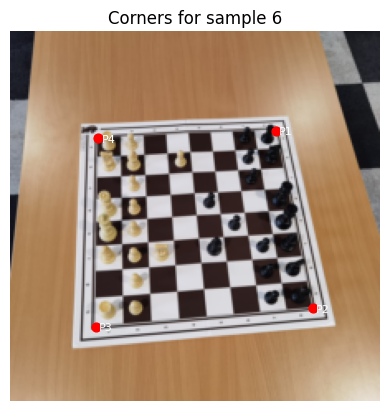

In [3]:
dataset = CornerDataset("/kaggle/input/dataset/dataset/annotations.json", "/kaggle/input/dataset/dataset/chessred2k/")
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = 16

train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, collate_fn=lambda x: x, num_workers=4, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size, collate_fn=lambda x: x, num_workers=4, pin_memory=True)

def visualize_sample(dataset, index=0, image_size= 224):
    image, corners = dataset[index]
    
    if isinstance(image, torch.Tensor):
        image = transforms.ToPILImage()(image)

    plt.imshow(image)
    corners = corners.reshape(4, 2) * image_size
    plt.scatter(corners[:, 0], corners[:, 1], c='red', s=40)
    for i, (x, y) in enumerate(corners):
        plt.text(x + 2, y + 2, f"P{i+1}", color='white', fontsize=8)
    plt.title(f"Corners for sample {index}")
    plt.axis('off')
    plt.show()

visualize_sample(dataset, index=6)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.resnet18(weights='DEFAULT')
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 8)
)
model.to(device)

def mean_point_error(preds, targets, image_size=224):
    preds_points = preds.view(preds.size(0), 4, 2) * image_size
    targets_points = targets.view(targets.size(0), 4, 2) * image_size

    per_point_errors = torch.sqrt(((preds_points - targets_points) ** 2).sum(dim=2)) 
    return per_point_errors.mean().item()


Using device: cpu


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 145MB/s]


In [5]:
def one_epoch(model, optimizer, dataloader, loss_fn, is_training):
    model.train() if is_training else model.eval()
    avg_loss = 0.0
    avg_mpe = 0.0

    for batch in dataloader:
        images = torch.stack([b[0] for b in batch]).to(device)
        targets = torch.stack([b[1] for b in batch]).to(device)

        with torch.set_grad_enabled(is_training):
            preds = model(images)
            loss = loss_fn(preds, targets.view(preds.size(0), -1))
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        avg_loss += loss.item() / len(dataloader)
        avg_mpe += mean_point_error(preds, targets) / len(dataloader)

    return avg_loss, avg_mpe

In [6]:
import copy 

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-2)
loss_fn = nn.MSELoss()

epochs = 150
patience = 5
best_val_metric = float('inf')
best_epoch = 0

for epoch in range(epochs):
    train_loss, train_mpe = one_epoch(model, optimizer, train_dataloader, loss_fn, True)
    val_loss, val_mpe = one_epoch(model, optimizer, val_dataloader, loss_fn, False)

    print(f"[Head Training] Epoch {epoch+1}: Train Loss = {train_loss:.4f}, MPE = {train_mpe:.4f} | Val Loss = {val_loss:.4f}, MPE = {val_mpe:.4f}")

    if val_mpe < best_val_metric:
        best_val_metric = val_mpe
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    elif epoch - best_epoch >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best validation MPE: {best_val_metric:.4f}")
        break

model.load_state_dict(best_model_state)

for param in model.parameters():
    param.requires_grad = True

[Head Training] Epoch 1: Train Loss = 0.0611, MPE = 72.9084 | Val Loss = 0.0588, MPE = 70.5970
[Head Training] Epoch 2: Train Loss = 0.0457, MPE = 62.2947 | Val Loss = 0.0416, MPE = 59.5651
[Head Training] Epoch 3: Train Loss = 0.0366, MPE = 54.1768 | Val Loss = 0.0387, MPE = 54.7379
[Head Training] Epoch 4: Train Loss = 0.0363, MPE = 53.1402 | Val Loss = 0.0305, MPE = 48.6036
[Head Training] Epoch 5: Train Loss = 0.0309, MPE = 48.4290 | Val Loss = 0.0331, MPE = 49.3142
[Head Training] Epoch 6: Train Loss = 0.0297, MPE = 46.7382 | Val Loss = 0.0259, MPE = 43.2241
[Head Training] Epoch 7: Train Loss = 0.0267, MPE = 44.3893 | Val Loss = 0.0249, MPE = 41.8650
[Head Training] Epoch 8: Train Loss = 0.0239, MPE = 41.1245 | Val Loss = 0.0228, MPE = 40.0387
[Head Training] Epoch 9: Train Loss = 0.0251, MPE = 42.2222 | Val Loss = 0.0236, MPE = 40.1983
[Head Training] Epoch 10: Train Loss = 0.0220, MPE = 38.9251 | Val Loss = 0.0224, MPE = 38.2969
[Head Training] Epoch 11: Train Loss = 0.0211, MP

In [7]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

In [8]:
import copy

epochs = 150
patience = 5
best_val_metric = float('inf')
best_epoch = 0
train_history = {'loss': [], 'metric': []}
val_history = {'loss': [], 'metric': []}

for epoch in range(epochs):
    train_loss, train_mpe = one_epoch(model, optimizer, train_dataloader, loss_fn, True)
    train_history['loss'].append(train_loss)
    train_history['metric'].append(train_mpe)

    val_loss, val_mpe = one_epoch(model, optimizer, val_dataloader, loss_fn, False)
    val_history['loss'].append(val_loss)
    val_history['metric'].append(val_mpe)

    print(f"Epoch {epoch+1:3d}/{epochs} - Train Loss: {train_loss:.4f}, MPE: {train_mpe:.4f} | Val Loss: {val_loss:.4f}, MPE: {val_mpe:.4f}")

    # Early stopping
    if val_mpe < best_val_metric:
        best_val_metric = val_mpe
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    elif epoch - best_epoch >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best validation MPE: {best_val_metric:.4f}")
        break

model.load_state_dict(best_model_state)

Epoch   1/150 - Train Loss: 0.0133, MPE: 24.0809 | Val Loss: 0.0087, MPE: 19.8757
Epoch   2/150 - Train Loss: 0.0074, MPE: 18.5440 | Val Loss: 0.0069, MPE: 17.9669
Epoch   3/150 - Train Loss: 0.0051, MPE: 15.6347 | Val Loss: 0.0027, MPE: 13.0185
Epoch   4/150 - Train Loss: 0.0030, MPE: 13.0362 | Val Loss: 0.0032, MPE: 12.5706
Epoch   5/150 - Train Loss: 0.0020, MPE: 11.2882 | Val Loss: 0.0018, MPE: 10.7562
Epoch   6/150 - Train Loss: 0.0012, MPE: 9.5821 | Val Loss: 0.0013, MPE: 9.4959
Epoch   7/150 - Train Loss: 0.0010, MPE: 8.6987 | Val Loss: 0.0013, MPE: 9.1727
Epoch   8/150 - Train Loss: 0.0009, MPE: 8.3003 | Val Loss: 0.0011, MPE: 8.6461
Epoch   9/150 - Train Loss: 0.0015, MPE: 9.1470 | Val Loss: 0.0016, MPE: 9.7329
Epoch  10/150 - Train Loss: 0.0011, MPE: 8.6099 | Val Loss: 0.0014, MPE: 8.7744
Epoch  11/150 - Train Loss: 0.0015, MPE: 8.7776 | Val Loss: 0.0028, MPE: 10.3568
Epoch  12/150 - Train Loss: 0.0023, MPE: 10.6824 | Val Loss: 0.0019, MPE: 9.9121
Epoch  13/150 - Train Loss: 

<All keys matched successfully>

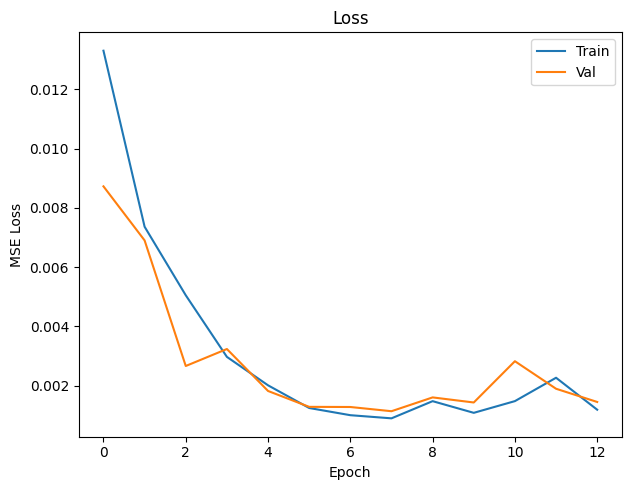

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_history['loss'], label='Train')
plt.plot(val_history['loss'], label='Val')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.tight_layout()
plt.show()

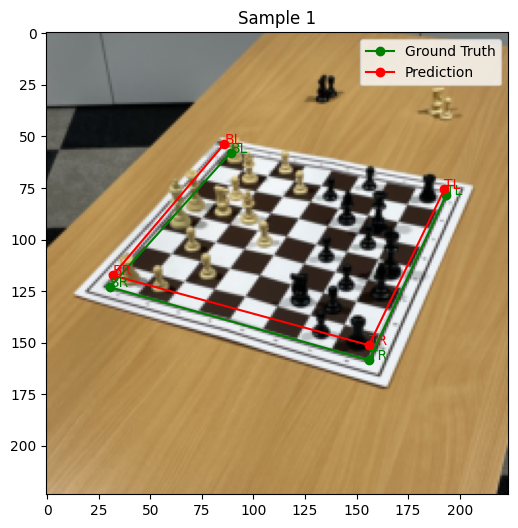

The corners are  [[193.6311    78.170364]
 [156.08444  158.53407 ]
 [ 30.41111  123.08741 ]
 [ 88.931114  57.94815 ]]
The predicted corners are  tensor([[192.6612,  75.5099],
        [156.0632, 151.2206],
        [ 31.8158, 117.3795],
        [ 85.9783,  53.5124]])


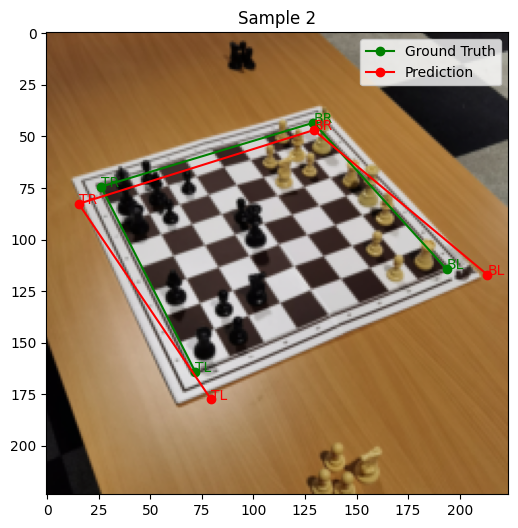

The corners are  [[ 71.81562  164.11063 ]
 [ 26.101978  74.39542 ]
 [129.1354    43.35625 ]
 [193.71698  114.4099  ]]
The predicted corners are  tensor([[ 79.5174, 177.5410],
        [ 15.3181,  82.6641],
        [129.2690,  46.9341],
        [213.4934, 117.0864]])


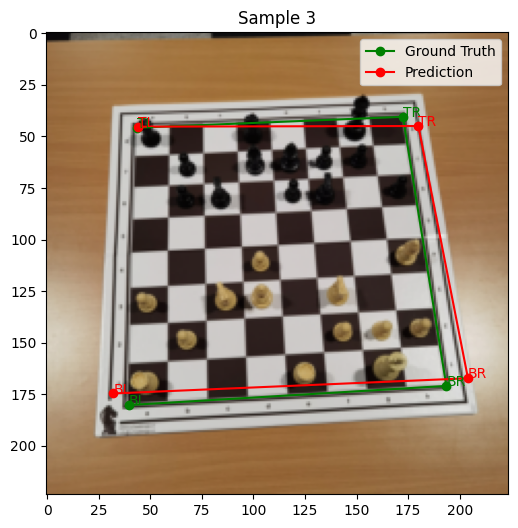

The corners are  [[ 43.580833  45.784374]
 [172.50624   40.476044]
 [193.5726   170.95168 ]
 [ 39.56167  180.25145 ]]
The predicted corners are  tensor([[ 44.0769,  45.2469],
        [179.9895,  44.9443],
        [204.0437, 167.2561],
        [ 32.1021, 174.6201]])


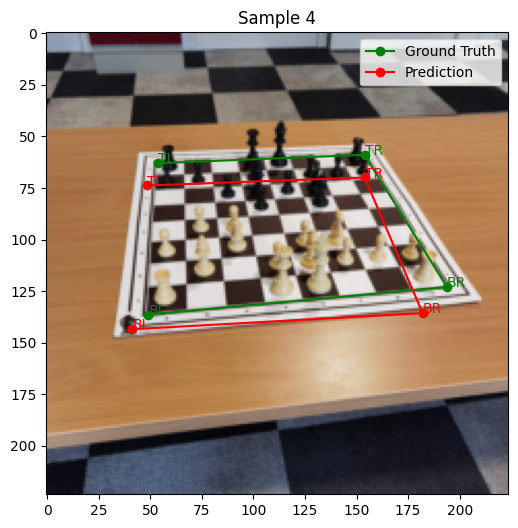

The corners are  [[ 53.980938  62.96646 ]
 [153.88771   58.917397]
 [193.86792  122.97323 ]
 [ 49.020416 136.38042 ]]
The predicted corners are  tensor([[ 48.4601,  73.7846],
        [153.9216,  69.9035],
        [182.0494, 135.6585],
        [ 41.3343, 143.4788]])


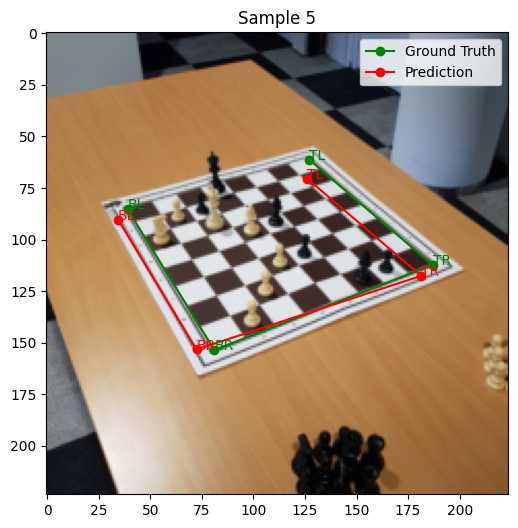

The corners are  [[126.978516  61.18593 ]
 [186.85777  112.3163  ]
 [ 81.09185  153.58148 ]
 [ 39.00296   85.35037 ]]
The predicted corners are  tensor([[126.2209,  70.5612],
        [181.3991, 117.5774],
        [ 72.4326, 153.2892],
        [ 34.4201,  90.4088]])


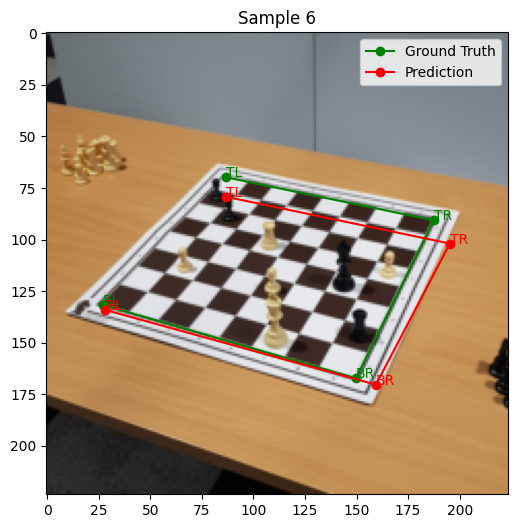

The corners are  [[ 86.91926   69.838524]
 [187.42815   90.68296 ]
 [149.76816  167.25555 ]
 [ 27.057037 131.68074 ]]
The predicted corners are  tensor([[ 86.9083,  79.2828],
        [195.2495, 101.9415],
        [159.4171, 170.3590],
        [ 28.1217, 134.0954]])


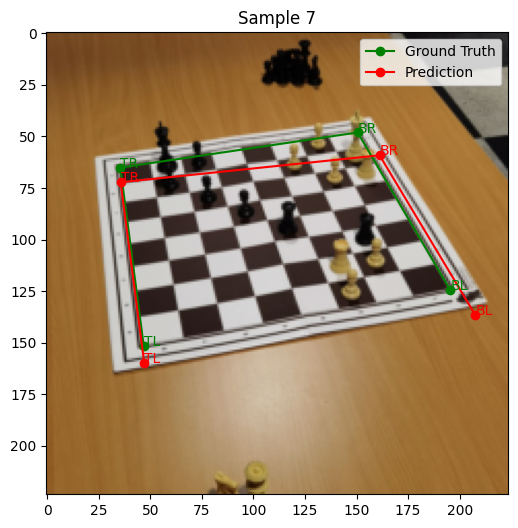

The corners are  [[ 46.8125   151.50479 ]
 [ 35.476875  65.11677 ]
 [150.55688   48.07177 ]
 [195.45532  124.433754]]
The predicted corners are  tensor([[ 47.1073, 159.9669],
        [ 35.6349,  72.2181],
        [161.1777,  59.1395],
        [207.6064, 136.5997]])


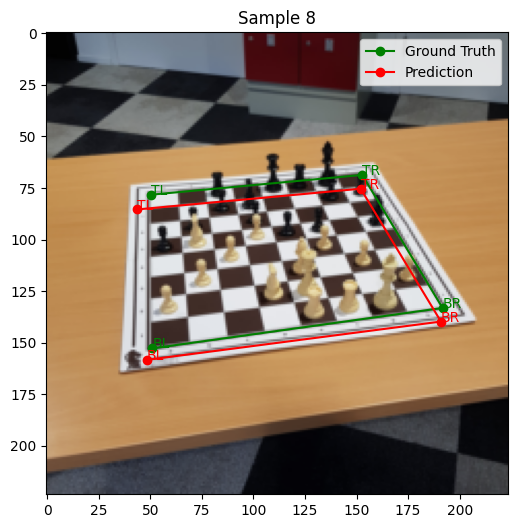

The corners are  [[ 50.515556  78.240746]
 [152.77333   68.656296]
 [191.71481  133.15704 ]
 [ 50.97333  152.7526  ]]
The predicted corners are  tensor([[ 43.5496,  85.4114],
        [152.0107,  75.3503],
        [190.9507, 139.7564],
        [ 48.2974, 158.3274]])


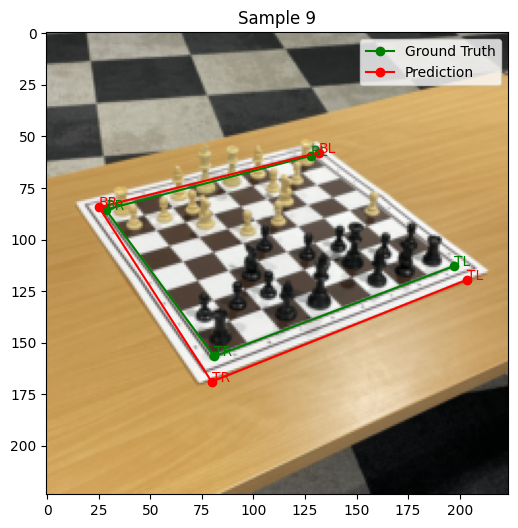

The corners are  [[197.34445  112.80963 ]
 [ 81.00222  156.65999 ]
 [ 28.370369  85.46963 ]
 [127.89629   59.3837  ]]
The predicted corners are  tensor([[203.6544, 119.4673],
        [ 79.7694, 168.9258],
        [ 25.1357,  84.3648],
        [131.6352,  57.7999]])


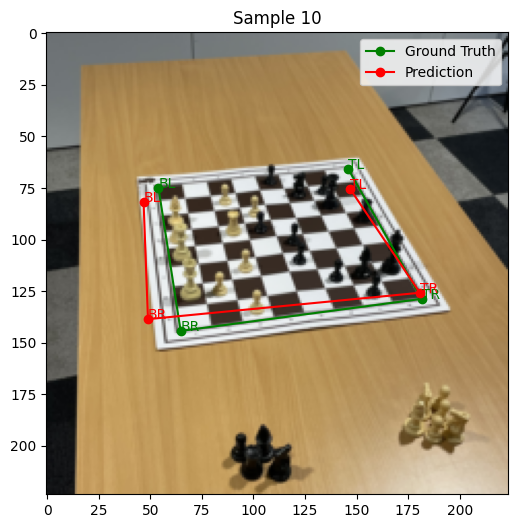

The corners are  [[146.10815   65.974075]
 [181.6037   128.7526  ]
 [ 64.72296  144.28073 ]
 [ 53.961483  74.80666 ]]
The predicted corners are  tensor([[146.8011,  75.2965],
        [180.7209, 125.7937],
        [ 48.8945, 138.5916],
        [ 46.7656,  81.9946]])


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_predictions(model, dataset, num_samples=5, image_size=224):
    model.eval()
    
    for i in range(num_samples):
        image, gt_corners = dataset[i]
        input_image = image.unsqueeze(0).to(device)

        with torch.no_grad():
            pred_corners = model(input_image).cpu().view(-1, 2) * image_size

        image_np = image.permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(1, figsize=(6, 6))
        ax.imshow(image_np)

        gt_corners_np = gt_corners.numpy().reshape(-1, 2) * image_size
        ax.plot(gt_corners_np[:, 0], gt_corners_np[:, 1], 'go-', label='Ground Truth')
        ax.plot(pred_corners[:, 0], pred_corners[:, 1], 'ro-', label='Prediction')

        for j, txt in enumerate(['TL', 'TR', 'BR', 'BL']):
            ax.annotate(txt, (gt_corners_np[j][0], gt_corners_np[j][1]), color='green')
            ax.annotate(txt, (pred_corners[j][0], pred_corners[j][1]), color='red')

        ax.legend()
        ax.set_title(f"Sample {i+1}")
        plt.show()
        print("The corners are " , gt_corners_np)
        print("The predicted corners are " , pred_corners)

visualize_predictions(model, val_dataloader.dataset, num_samples=10)
